# SME_Python — Ejemplo de uso

Este notebook muestra cómo instalar y utilizar **SME_Python**, una librería orientada al preprocesamiento y análisis de datasets.

A lo largo del notebook utilizaremos un dataset real de vehículos para mostrar, de forma progresiva, las principales funcionalidades en el paquete.

## Contenido

1. Instalación e importación del paquete
2. Carga y exploración del dataset
3. Discretización de variables
4. Cálculo de métricas
5. Normalización y estandarización
6. Filtrado de variables
7. Correlación e información mutua
8. Visualización de resultados


## Durnate la creación del paquete

Se ha intentado mantener un estilo de API publica (ej. discretizar()) que llama a funciones internas (_discretizar_frecuencia) que el usuario no puede ver, haciendo un 'router' interno para segun el caso.

Tambien se ha hecho incapie en un sistema de printeo de informacion a distintos niveles (_verbose) y se ha intentado tratar de gestionar todos los errores, warnings... mediante el uso de _verbose y raise_error.

## 1. Instalación e importación

En primer lugar instalamos la versión disponible del paquete directamente desde GitHub. De esta forma podemos comprobar que el proyecto puede instalarse correctamente como una librería de Python.

In [1]:
%pip install "git+https://github.com/EnZaFe/SME_paquetes.git#subdirectory=python"

  Cloning https://github.com/EnZaFe/SME_paquetes.git to c:\users\burbu\appdata\local\temp\pip-req-build-45nd_xsb
  Resolved https://github.com/EnZaFe/SME_paquetes.git to commit 6b157f9002908921ad3e59104ee2d77fce054c95
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/EnZaFe/SME_paquetes.git 'C:\Users\Burbu\AppData\Local\Temp\pip-req-build-45nd_xsb'

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Comprobación de la instalación

Comprobamos que el paquete se puede importar correctamente y mostramos la versión instalada.

In [2]:
import SME_python as sme

print(sme.__version__)
print(sme.__file__)

0.1.1
c:\Users\Burbu\Desktop\SME_Python\.venv\Lib\site-packages\SME_python\__init__.py


## 2. Dataset

Para probar las funcionalidades de la librería utilizaremos el **Vehicle Dataset from CarDekho**.

El dataset contiene información sobre vehículos de segunda mano e incluye tanto variables numéricas como categóricas.

Entre las variables disponibles encontramos:

- `Year`: año del vehículo.
- `Selling_Price`: precio de venta.
- `Present_Price`: precio actual estimado.
- `Kms_Driven`: kilómetros recorridos.
- `Fuel_Type`: tipo de combustible.
- `Seller_Type`: tipo de vendedor.
- `Transmission`: tipo de transmisión.
- `Owner`: número de propietarios anteriores.

### Descarga del dataset

Utilizamos `kagglehub` para descargar el dataset directamente desde Kaggle.

In [3]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import pandas as pd
import kagglehub

path = kagglehub.dataset_download(
    "nehalbirla/vehicle-dataset-from-cardekho"
)

print("Dataset descargado en:", path)

Dataset descargado en: C:\Users\Burbu\.cache\kagglehub\datasets\nehalbirla\vehicle-dataset-from-cardekho\versions\4


El dataset descargado contiene varios archivos CSV. Para este ejemplo utilizaremos `car data.csv`, que contiene una versión compacta y adecuada para mostrar las funcionalidades de la librería.

In [5]:
os.listdir(path)

['car data.csv',
 'CAR DETAILS FROM CAR DEKHO.csv',
 'Car details v3.csv',
 'car details v4.csv']

In [6]:
df = pd.read_csv(
    os.path.join(path, "car data.csv")
)

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Exploración inicial

Antes de aplicar las funciones de `SME_Python`, comprobamos las dimensiones del dataset, sus columnas y los tipos de datos.

In [7]:
df.shape

(301, 9)

In [8]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


También podemos consultar algunas estadísticas descriptivas de las variables numéricas.

In [10]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## 3. Discretización de variables

La discretización permite transformar variables numéricas continuas en intervalos.

`SME_Python` proporciona dos metodos:

- **Anchura (`anchura`)**: divide el rango de valores en intervalos de igual amplitud.
- **Frecuencia (`frecuencia`)**: construye intervalos intentando mantener una cantidad similar de observaciones en cada uno.

La función también permite seleccionar qué columnas discretizar y controlar el número de intervalos o la frecuencia deseada.

### 3.1. Discretización automática

Si no especificamos las columnas, la función identifica las variables numéricas susceptibles de ser discretizadas.

Si tampoco indicamos el número de intervalos, la función utiliza su criterio predeterminado para determinarlo.

In [11]:
df_discret = sme.discretizar(df)

df_discret.head()

Iniciando discretizacion...


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,"(2013.9, 2014.0)","(3.12, 3.36)","(5.24, 5.86)","(23810.0, 27140.0)",Petrol,Dealer,Manual,"(0.0, 0.02)"
1,sx4,"(2012.9, 2013.0)","(4.52, 4.75)","(8.93, 9.55)","(40460.0, 43790.0)",Diesel,Dealer,Manual,"(0.0, 0.02)"
2,ciaz,"(2016.9, 2017.0)","(7.08, 7.31)","(9.55, 10.16)","(3830.0, 7160.0)",Petrol,Dealer,Manual,"(0.0, 0.02)"
3,wagon r,"(2010.9, 2011.0)","(2.66, 2.89)","(4.01, 4.63)","(3830.0, 7160.0)",Petrol,Dealer,Manual,"(0.0, 0.02)"
4,swift,"(2013.9, 2014.0)","(4.52, 4.75)","(6.47, 7.09)","(40460.0, 43790.0)",Diesel,Dealer,Manual,"(0.0, 0.02)"


### 3.2. Discretización por igual anchura

Podemos seleccionar una variable concreta y especificar el número de intervalos que queremos utilizar.

En este caso dividiremos `Kms_Driven` en 10 intervalos de igual anchura.

In [12]:
df_discret = sme.discretizar(
    df,
    columnas=["Kms_Driven"],
    metodo="anchura",
    n_intervalos=10,
    verbose=2
)

df_discret.head()

Iniciando discretizacion...
Parametros elegidos: 
    metodo: anchura, 
    n_intervalos: 10, 
    frecuenca: None, 
    columnas: ['Kms_Driven']
             
Número de casos: 301
Mínimo: 500.0
Máximo: 500000.0
Anchura de los intervalos: 49950.0
Límites de los intervalos: [500.0, 50450.0, 100400.0, 150350.0, 200300.0, 250250.0, 300200.0, 350150.0, 400100.0, 450050.0, 500000.0]


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,"(500.0, 50450.0)",Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,"(500.0, 50450.0)",Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,"(500.0, 50450.0)",Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,"(500.0, 50450.0)",Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,"(500.0, 50450.0)",Diesel,Dealer,Manual,0


### 3.3. Discretización por igual frecuencia

También podemos utilizar el método de igual frecuencia.

En este caso los intervalos se construyen de manera que contengan, aproximadamente, el mismo número de observaciones.

In [13]:
df_discret = sme.discretizar(
    df,
    columnas=["Kms_Driven"],
    metodo="frecuencia",
    n_intervalos=10,
    verbose=2
)

df_discret.head()

Iniciando discretizacion...
Parametros elegidos: 
    metodo: frecuencia, 
    n_intervalos: 10, 
    frecuenca: None, 
    columnas: ['Kms_Driven']
             
Número de casos: 301
Frecuencia base calculada: 30
Elementos sobrantes: 1
Valores ordenados: [500, 500, 1000, 1200, 1300, 1300, 1400, 1900, 2071, 2135]


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,"(24678.0, 32000.0)",Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,"(39000.0, 45000.0)",Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,"(6000.0, 12900.0)",Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,"(500.0, 6000.0)",Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,"(39000.0, 45000.0)",Diesel,Dealer,Manual,0


### 3.4. Especificar directamente la frecuencia

Otra posibilidad es indicar directamente cuántas observaciones queremos aproximadamente en cada intervalo.

La función se encarga de calcular automáticamente los límites necesarios.

In [14]:
df_discret = sme.discretizar(
    df,
    columnas=["Kms_Driven"],
    metodo="frecuencia",
    frecuencia=10,
    verbose=2
)

df_discret.head()

Iniciando discretizacion...
Parametros elegidos: 
    metodo: frecuencia, 
    n_intervalos: None, 
    frecuenca: 10, 
    columnas: ['Kms_Driven']
             
Número de casos: 301
Elementos sobrantes: 1
Valores ordenados: [500, 500, 1000, 1200, 1300, 1300, 1400, 1900, 2071, 2135]


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,"(26000.0, 29223.0)",Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,"(43000.0, 45000.0)",Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,"(6000.0, 8000.0)",Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,"(4492.0, 6000.0)",Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,"(40126.0, 42450.0)",Diesel,Dealer,Manual,0


## 4. Cálculo de métricas

Una vez que hemos visto cómo transformar las variables, podemos calcular diferentes métricas para estudiar sus características.

Podemos calcular:

- **Entropía** para variables discretas.
- **Varianza** para variables numéricas.
- **AUC** cuando disponemos y asignamos una variable de objetivo binaria, es decir, 2 clases.

Estas métricas pueden utilizarse posteriormente para seleccionar o filtrar variables.

In [15]:
metricas = sme.calcular_metricas(df)

metricas

Iniciando cálculo de métricas...
No se han especificado atributos. Se analizarán las 9 columnas del dataset.
Cálculo de métricas finalizado correctamente.


{'Car_Name': {'entropia': 5.940473563156922},
 'Year': {'varianza': 8.33330757938651},
 'Selling_Price': {'varianza': 25.749142839483014},
 'Present_Price': {'varianza': 74.47248945186031},
 'Kms_Driven': {'varianza': 1507165851.8844826},
 'Fuel_Type': {'entropia': 0.7760761457168116},
 'Seller_Type': {'entropia': 0.9359818715607877},
 'Transmission': {'entropia': 0.5653120724399866},
 'Owner': {'varianza': 0.061257602013223354}}

También podemos calcular las métricas sobre un conjunto concreto de variables y asignando clases para el calculo de AUC.

In [16]:
metricas = sme.calcular_metricas(
    df,
    clases=df["Transmission"]
)

metricas

Iniciando cálculo de métricas...
No se han especificado atributos. Se analizarán las 9 columnas del dataset.
Cálculo de métricas finalizado correctamente.


{'Car_Name': {'entropia': 5.940473563156922},
 'Year': {'varianza': 8.33330757938651, 'auc': 0.5324712643678161},
 'Selling_Price': {'varianza': 25.749142839483014, 'auc': 0.6611590038314177},
 'Present_Price': {'varianza': 74.47248945186031, 'auc': 0.6838122605363984},
 'Kms_Driven': {'varianza': 1507165851.8844826, 'auc': 0.5206417624521072},
 'Fuel_Type': {'entropia': 0.7760761457168116},
 'Seller_Type': {'entropia': 0.9359818715607877},
 'Transmission': {'entropia': 0.5653120724399866},
 'Owner': {'varianza': 0.061257602013223354, 'auc': 0.5061781609195402}}

## 5. Normalización y estandarización

La librería incluye dos transformaciones habituales para preparar variables numéricas:

- **Normalización**: transforma los valores al rango `[0, 1]`.
- **Estandarización**: transforma los valores para trabajar alrededor de una media de 0 y una desviación estándar de 1.

En ambos casos podemos indicar las variables que queremos transformar.

In [17]:
df_normalizado = sme.normalizar(
    df,
    atributos=["Selling_Price", "Present_Price", "Kms_Driven"]
)

df_normalizado.head()

Iniciando normalización...


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,0.093123,0.057109,0.053053,Petrol,Dealer,Manual,0
1,sx4,2013,0.133238,0.099913,0.085085,Diesel,Dealer,Manual,0
2,ciaz,2017,0.204871,0.103273,0.012813,Petrol,Dealer,Manual,0
3,wagon r,2011,0.078797,0.041504,0.009409,Petrol,Dealer,Manual,0
4,swift,2014,0.128940,0.070980,0.083984,Diesel,Dealer,Manual,0


In [18]:
df_estandarizado = sme.estandarizar(
    df,
    atributos=["Selling_Price", "Present_Price", "Kms_Driven"],
)

df_estandarizado.head()

Iniciando estandarización...


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,-0.257986,-0.235822,-0.255798,Petrol,Dealer,Manual,0
1,sx4,2013,0.017452,0.221136,0.155651,Diesel,Dealer,Manual,0
2,ciaz,2017,0.509306,0.256999,-0.772682,Petrol,Dealer,Manual,0
3,wagon r,2011,-0.356357,-0.402409,-0.816399,Petrol,Dealer,Manual,0
4,swift,2014,-0.012059,-0.087744,0.141508,Diesel,Dealer,Manual,0


## 6. Filtrado de variables

Una vez calculadas las métricas podemos utilizarlas para seleccionar variables.

La función `filtrar_variables` permite conservar o descartar variables según un umbral determinado.

El criterio utilizado depende del tipo de variable y de la métrica seleccionada.

Si no se le dan los datos, hace los calculos automaticamente.

In [19]:
df_filtrado = sme.filtrar_variables(
    df,
    entropia=[0.3, 0.4],
    modo="dentro"
)
eliminadas = set(df.columns) - set(df_filtrado.columns)

print("Variables eliminadas:", len(eliminadas))
print(eliminadas)

Iniciando filtrado de variables...
Iniciando cálculo de métricas...
No se han especificado atributos. Se analizarán las 9 columnas del dataset.
Cálculo de métricas finalizado correctamente.
Variables eliminadas: 4
{'Seller_Type', 'Car_Name', 'Fuel_Type', 'Transmission'}


Se pueden usar como umbrales: la entropia la vaianza y AUC. Se recomienda hacer una normalizacion o estandarizacion antes de utilizar el filtro.

Tambien tiene tanto modo 'dentro' como 'fuera' del rango que se le añada a cada umbral.

Destacar que permite el uso de multiples umbrales al mismo tiempo, donde se aplica discreto a los discretos y numerico a los numericos. AUnque varianza y AUC a la vez hacen and. 

In [20]:
df_filtrado = sme.filtrar_variables(
    df_estandarizado,
    #entropia=[0.3, 0.4],
    varianza=[0.3,0.5],
    modo="dentro",
)
eliminadas = set(df.columns) - set(df_filtrado.columns)

print("Variables eliminadas:", len(eliminadas))
print(eliminadas)

Iniciando filtrado de variables...
Iniciando cálculo de métricas...
No se han especificado atributos. Se analizarán las 9 columnas del dataset.
Cálculo de métricas finalizado correctamente.
Variables eliminadas: 5
{'Year', 'Kms_Driven', 'Selling_Price', 'Present_Price', 'Owner'}


De todas maneras se puede hacer en 2 partes y eligiendo los atributos que se desee.

In [21]:
metricas = sme.calcular_metricas(df_estandarizado)

df_filtrado = sme.filtrar_variables(
    dataset=df_estandarizado,
    #entropia=[0.3, 0.4],
    varianza=[0.3,0.5],
    modo="dentro",
    metricas=metricas,
    verbose=2
)
eliminadas = set(df.columns) - set(df_filtrado.columns)

print("Variables eliminadas:", len(eliminadas))
print(eliminadas)

Iniciando cálculo de métricas...
No se han especificado atributos. Se analizarán las 9 columnas del dataset.
Cálculo de métricas finalizado correctamente.
Iniciando filtrado de variables...
Variables eliminadas: 5
{'Year', 'Kms_Driven', 'Selling_Price', 'Present_Price', 'Owner'}


## 7. Correlación e información mutua

`SME_Python` permite estudiar diferentes tipos de relación entre variables dependiendo de su naturaleza:

- **Pearson** para variables numéricas.
- **Información mutua** para variables categóricas.
- **Welch** para estudiar la relación entre una variable categórica y una numérica.

La función selecciona el cálculo apropiado en función del tipo de variables.

In [22]:
correlaciones = sme.calcular_correlacion(df)

correlaciones

Iniciando cálculo de correlaciones...
Se analizarán 9 atributos.
Cálculo de correlaciones finalizado.


c:\Users\Burbu\Desktop\SME_Python\.venv\Lib\site-packages\SME_python\correlacion_info.py:296: RuntimeWarning: overflow encountered in scalar multiply
  denominador = (parte_x * parte_y) ** 0.5
c:\Users\Burbu\Desktop\SME_Python\.venv\Lib\site-packages\SME_python\correlacion_info.py:296: RuntimeWarning: invalid value encountered in power
  denominador = (parte_x * parte_y) ** 0.5


(                   Car_Name      Year  Selling_Price  Present_Price  \
 Car_Name       1.000000e+00  4.618807     128.380259   8.415476e+30   
 Year           4.618807e+00  1.000000       0.236141  -4.758421e-02   
 Selling_Price  1.283803e+02  0.236141       1.000000   8.789825e-01   
 Present_Price  8.415476e+30 -0.047584       0.878983   1.000000e+00   
 Kms_Driven     5.130938e+01       NaN       0.029187   2.036470e-01   
 Fuel_Type      2.741088e-01  0.756763      28.123149   1.362134e+01   
 Seller_Type    6.188978e-01  0.426765     213.102349   1.608961e+02   
 Transmission   2.193365e-01  0.000035      15.253248   1.973046e+01   
 Owner          1.758120e-01 -0.182104      -0.088344   8.057015e-03   
 
                Kms_Driven  Fuel_Type  Seller_Type  Transmission     Owner  
 Car_Name        51.309375   0.274109     0.618898      0.219336  0.175812  
 Year                  NaN   0.756763     0.426765      0.000035 -0.182104  
 Selling_Price    0.029187  28.123149   213.102

## 8. Visualización de resultados

Finalmente, la librería incorpora funciones de visualización para representar los resultados de algunos de los análisis anteriores.

Entre ellas encontramos visualizaciones para:

- AUC.
- Correlaciones de Pearson.
- Información mutua.
- Estadísticos de Welch.

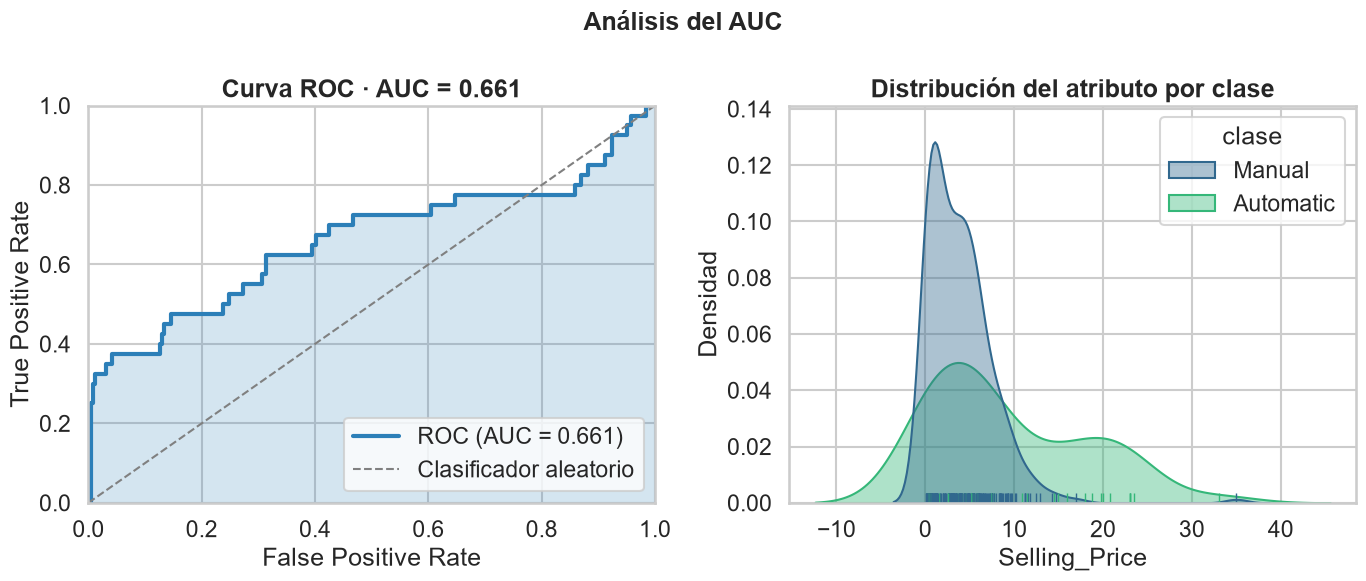

In [23]:
fig = sme.graficar_auc(
    df["Selling_Price"],
    df["Transmission"]
)

In [24]:
resultado

NameError: name 'resultado' is not defined

In [ ]:

# Si no tenemos los resultados los calculara automaticamente
fig1 = sme.graficar_pearson(
    df["Kms_Driven"],
    df["Selling_Price"]
)
#Si los tenemos nosotros podemos meterlos directamente
resultado = sme.calcular_correlacion(
    df,
    atributos=["Kms_Driven", "Selling_Price"]
)

fig2 = sme.graficar_pearson(
    df["Kms_Driven"],
    df["Selling_Price"],
    resultado=resultado[1][("Kms_Driven","Selling_Price")]
)


Iniciando cálculo de correlaciones...
Se analizarán 2 atributos.
Cálculo de correlaciones finalizado.


Veamos los dos graficos uno al lado del otro...


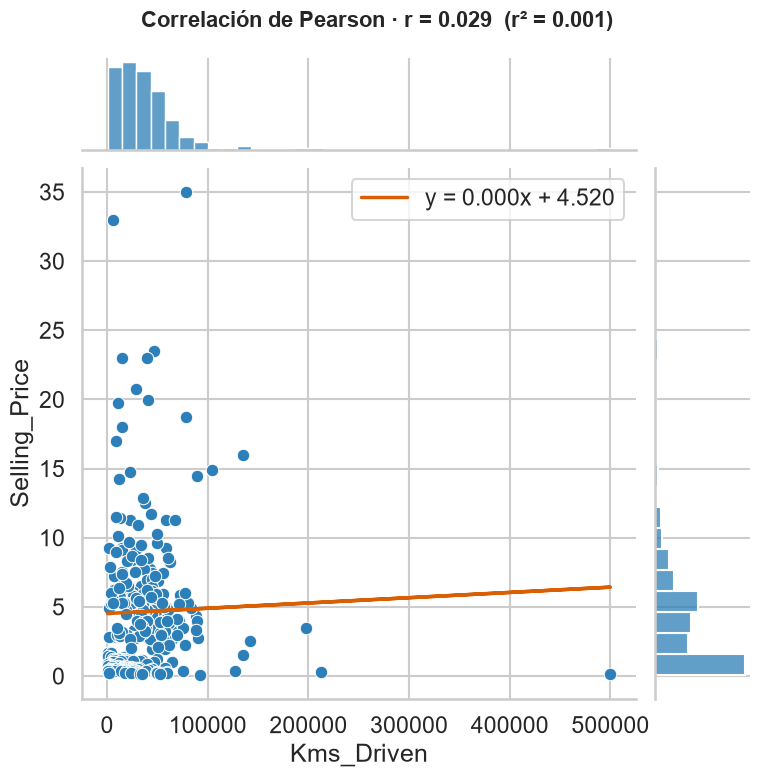
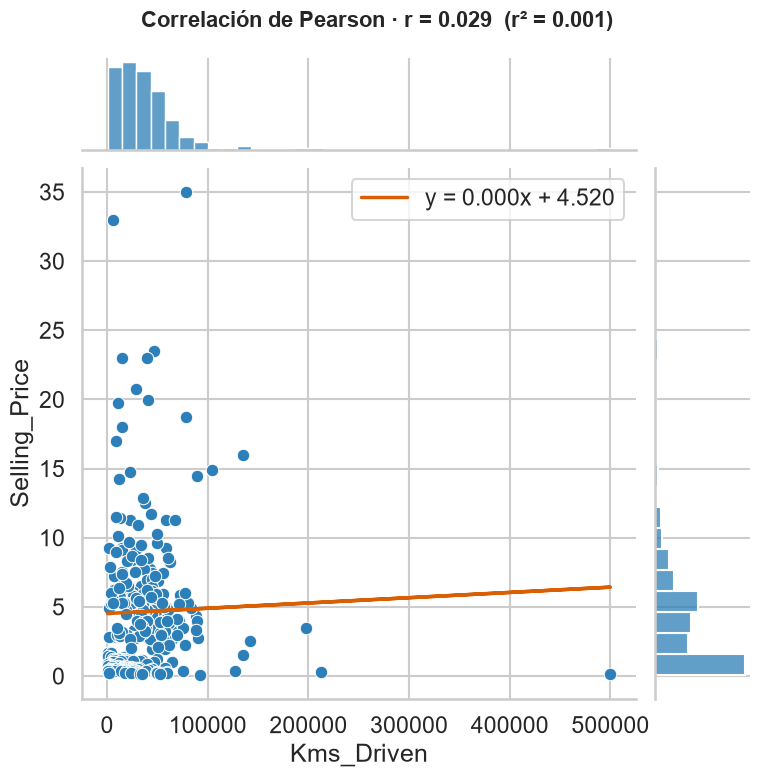

In [ ]:
from io import BytesIO
from IPython.display import display, HTML
import base64

def figura_a_base64(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    buffer.seek(0)
    return base64.b64encode(buffer.read()).decode()

img1 = figura_a_base64(fig1)
img2 = figura_a_base64(fig2)

display(HTML(f"""
<div style="display:flex; gap:20px;">
    <img src="data:image/png;base64,{img1}" style="width:48%;">
    <img src="data:image/png;base64,{img2}" style="width:48%;">
</div>
"""))

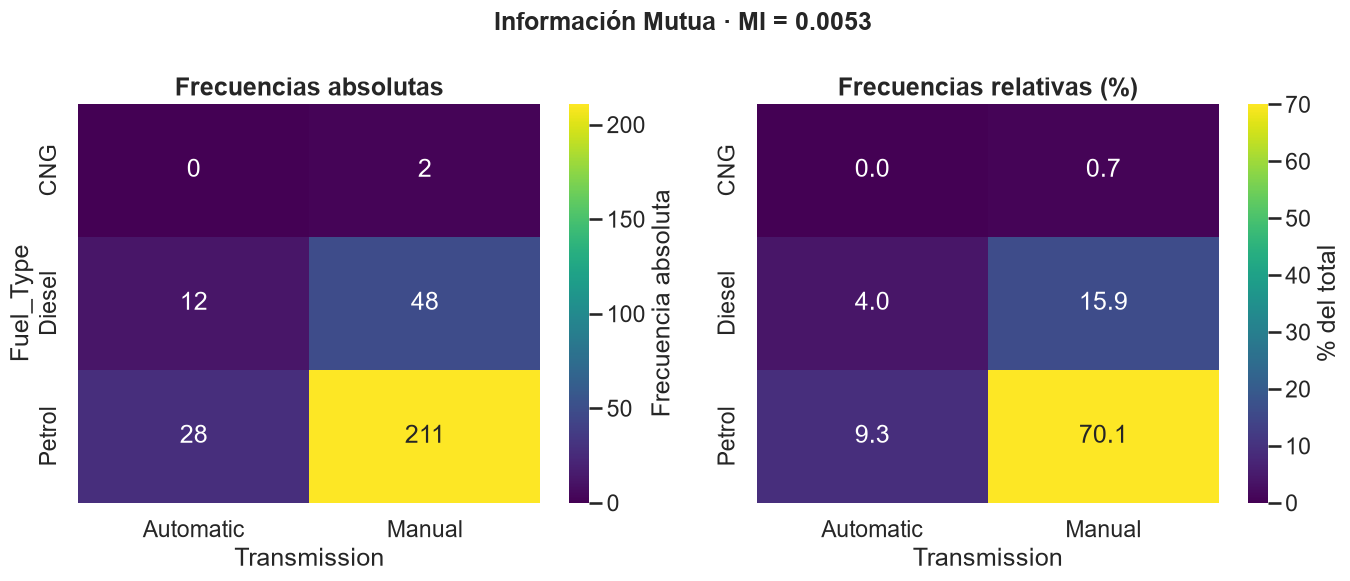

In [ ]:
fig = sme.graficar_informacion_mutua(
    df["Fuel_Type"],
    df["Transmission"]
)

c:\Users\Burbu\Desktop\SME_Python\.venv\Lib\site-packages\SME_python\visualizacion.py:411: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


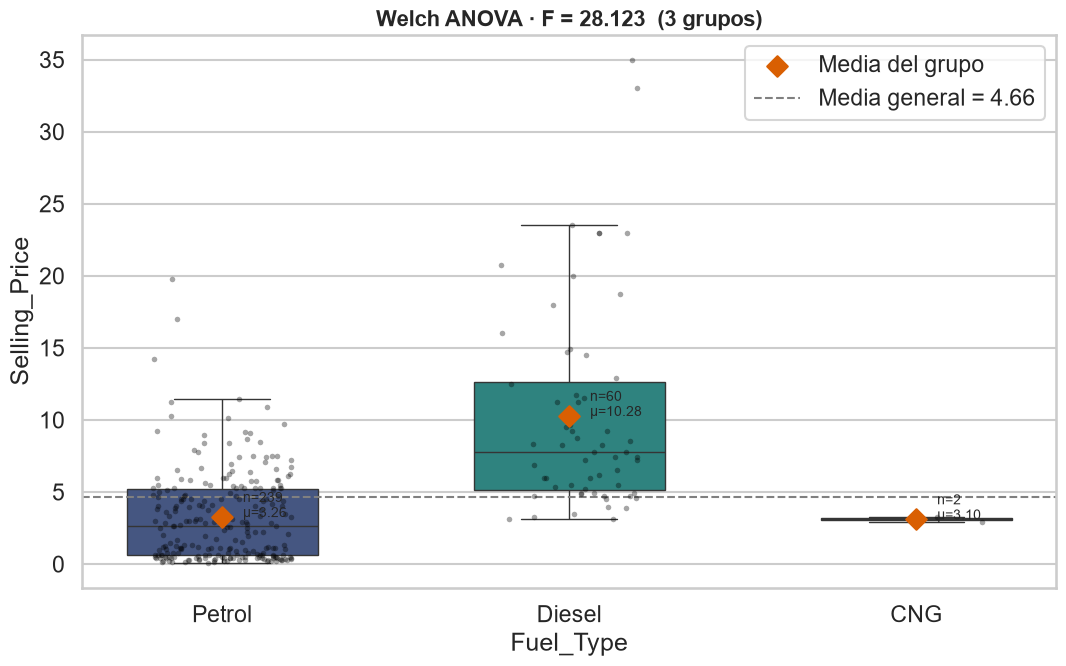

In [ ]:
fig = sme.graficar_welch(
    df["Fuel_Type"],
    df["Selling_Price"]
)

## Conclusión

A lo largo de este notebook hemos recorrido las principales funcionalidades de `SME_Python`, desde la preparación de los datos hasta el cálculo de métricas, transformación y selección de variables, análisis de relaciones y visualización de resultados.

El objetivo es mostrar cómo las diferentes funciones de la librería pueden integrarse en un flujo de trabajo de análisis y preprocesamiento de datos.